# DASH Experiment Results Explorer

Lightweight notebook for loading and visualizing results generated by
`run_experiments.py` **or** `run_experiments_parallel.py`.

Both runners produce identical JSON output formats, so this notebook works
with either. No heavy computation here — just load JSON + plot.

**Prerequisites:** Run the experiment script first:
```bash
python run_experiments_parallel.py                           # all experiments (faster)
python run_experiments_parallel.py --experiments linear_sweep # or pick one
python run_experiments.py                                     # original (also works)
```

In [ ]:
import time
time.sleep(48 * 3600)

In [26]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Image

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

RESULTS = Path('../results')
TABLES = RESULTS / 'tables'
FIGURES = RESULTS / 'figures'

# Method colors and markers — kept in sync with run_experiments.py
METHOD_COLORS = {
    'Single Best': '#95a5a6',
    'Single Best (M=200)': '#7f8c8d',
    'Large Single Model': '#e74c3c',
    'LSM (Tuned)': '#c0392b',
    'Ensemble SHAP': '#9b59b6',
    'Naive Top-N': '#f39c12',
    'Stochastic Retrain': '#e67e22',
    'Random Selection': '#d4ac0d',
    'DASH (Dedup)': '#3498db',
    'DASH (MaxMin)': '#2ecc71',
    'DASH (Cluster)': '#1abc9c',
    'Random Forest': '#16a085',
    'Permutation Importance': '#8e44ad',
}

METHOD_MARKERS = {
    'Single Best': 's',
    'Single Best (M=200)': 'S',
    'Large Single Model': 'X',
    'LSM (Tuned)': 'x',
    'Ensemble SHAP': 'D',
    'Naive Top-N': '^',
    'Stochastic Retrain': 'v',
    'Random Selection': 'd',
    'DASH (MaxMin)': 'o',
    'DASH (Cluster)': 'P',
    'Random Forest': 'H',
    'Permutation Importance': 'p',
}

def load(name):
    """Load a results JSON, returning None if it doesn't exist yet."""
    path = TABLES / f'{name}.json'
    if not path.exists():
        print(f'⚠ {path} not found — run the corresponding experiment first.')
        return None
    with open(path) as f:
        return json.load(f)

def show_figure(name):
    """Display a saved figure if it exists."""
    path = FIGURES / name
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f'⚠ {path} not found.')

# Show which results are available
available = sorted(p.stem for p in TABLES.glob('*.json')) if TABLES.exists() else []
print(f'Available results: {available or "(none — run experiments first)"}')

Available results: ['benchmark_v6_frozen', 'first_mover_visualization', 'k_sweep_independence', 'overlapping', 'synthetic_linear_sweep']


---
## 1. Synthetic Linear Sweep

In [ ]:
sweep = load('synthetic_linear_sweep')
if sweep:
    rows = []
    for rho, methods in sorted(((k, v) for k, v in sweep.items() if not k.startswith('_')), key=lambda x: float(x[0])):
        for method, m in methods.items():
            row = {
                'rho': float(rho),
                'Method': method,
                'Stability': m.get('stability'),
                'Stability CI': f"[{m['stability_ci_lo']:.3f}, {m['stability_ci_hi']:.3f}]"
                    if 'stability_ci_lo' in m else '',
                'DGP Agreement': m.get('accuracy_mean'),
                'Equity (CV)': m.get('equity_mean'),
                'RMSE': m.get('rmse_mean', np.nan),
            }
            if m.get('k_eff_mean') is not None:
                row['K_eff'] = f"{m['k_eff_mean']:.1f}\u00b1{m.get('k_eff_std', 0):.1f}"
            rows.append(row)
    df_sweep = pd.DataFrame(rows)
    display(df_sweep.pivot_table(index='Method', columns='rho', values='Stability').round(4))
    print('\nFull table:')
    display(df_sweep.round(4))


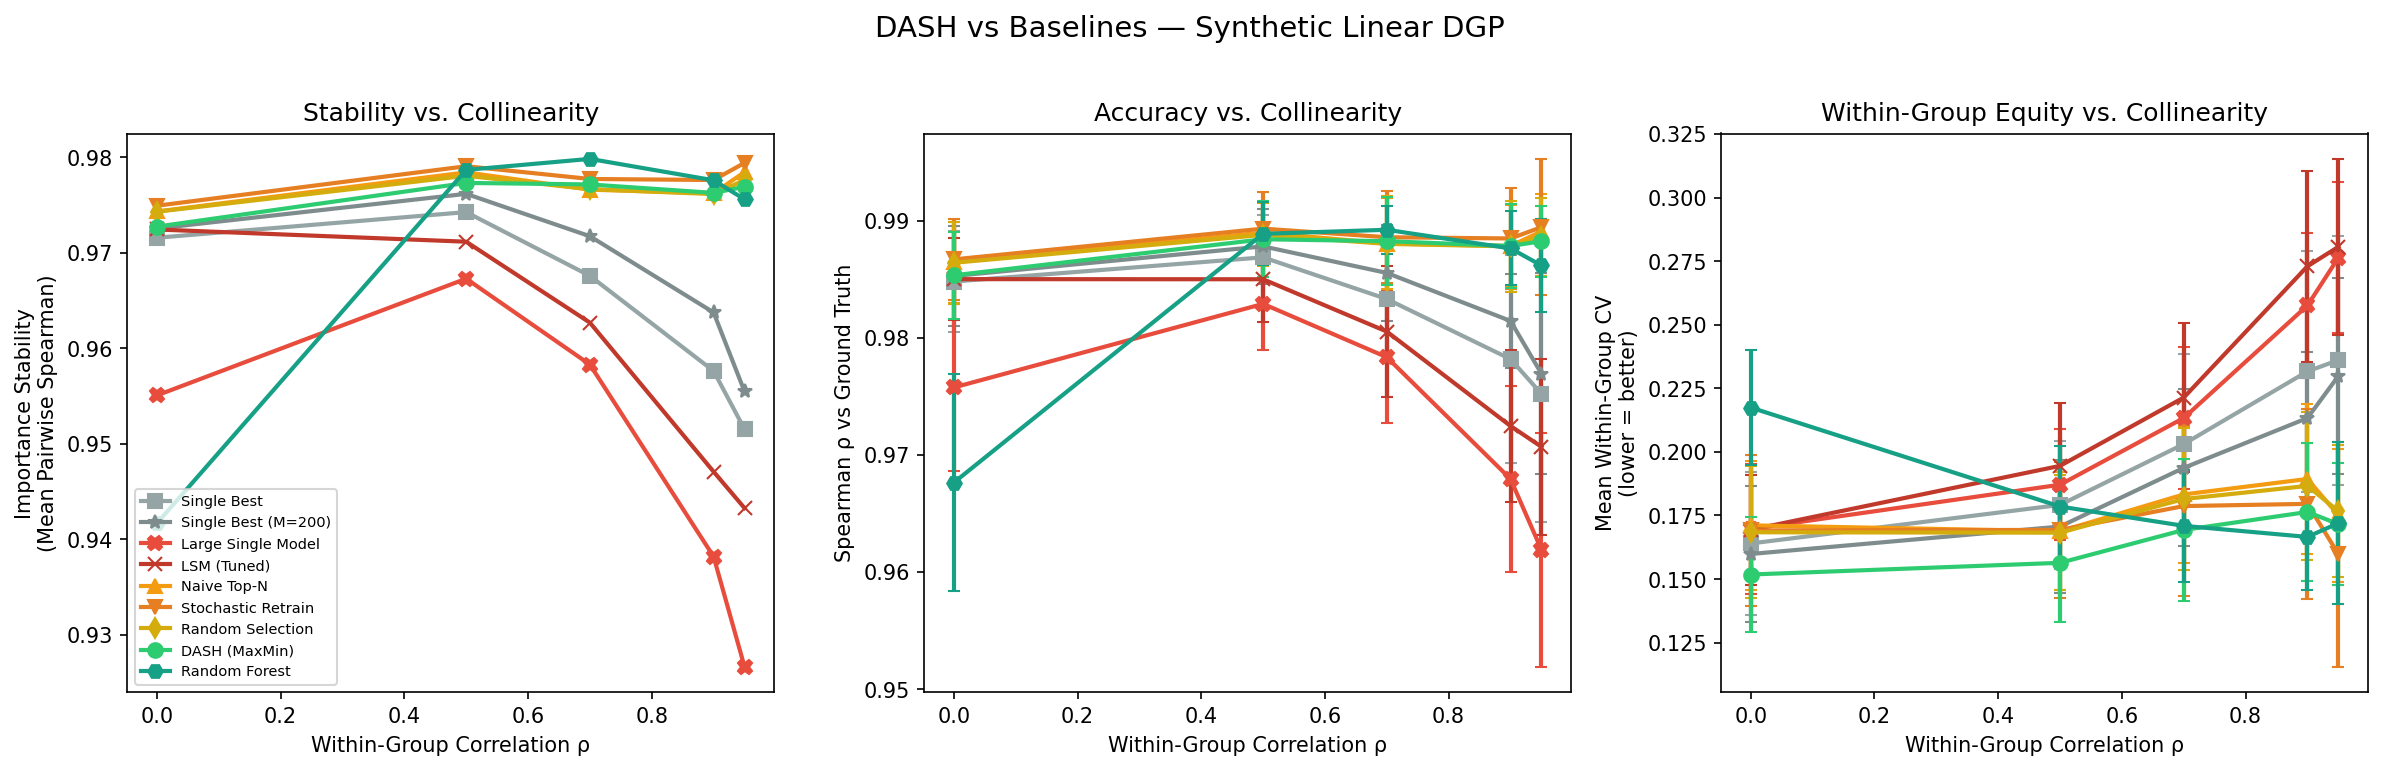

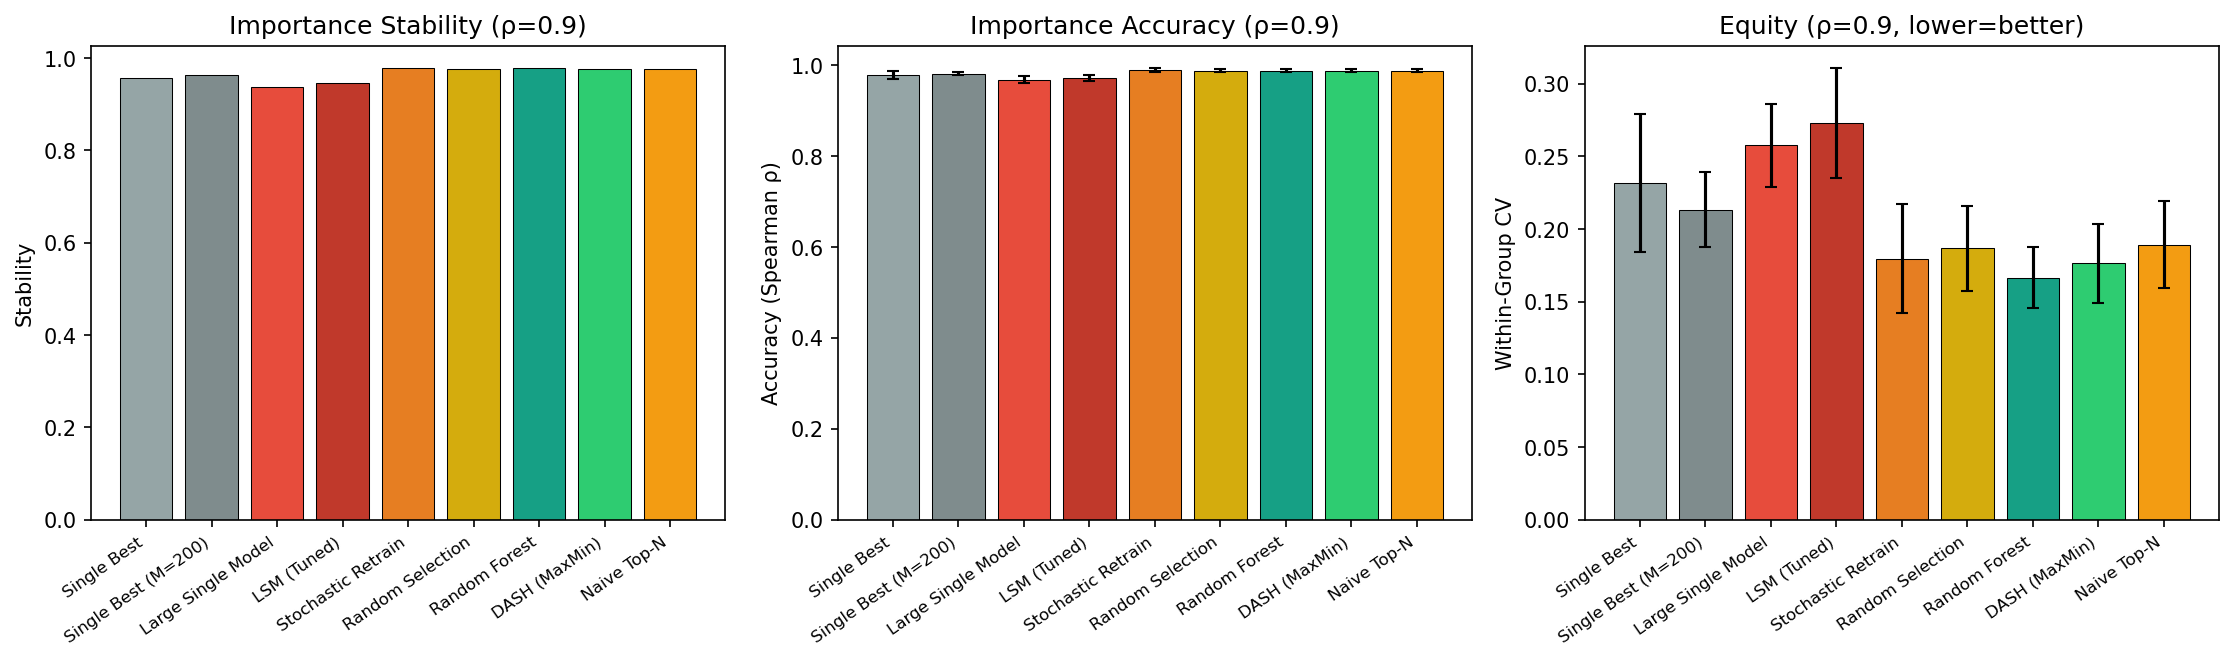

In [28]:
# Auto-generated figures from the script
show_figure('correlation_sweep.png')
show_figure('bar_chart_rho09.png')

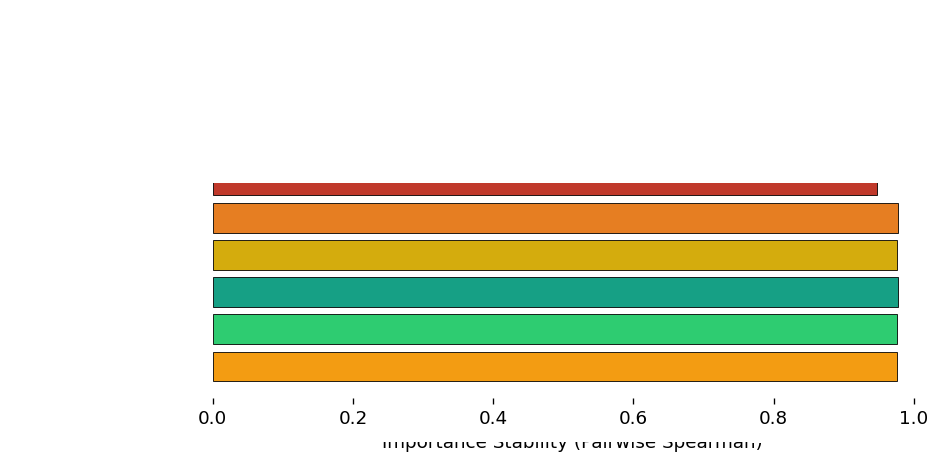

In [29]:
# Custom plot: stability comparison at high correlation
if sweep and '0.9' in sweep:
    methods = list(sweep['0.9'].keys())
    stab = [sweep['0.9'][m]['stability'] for m in methods]

    fig, ax = plt.subplots(figsize=(8, 4))
    colors = [METHOD_COLORS.get(m, '#95a5a6') for m in methods]
    ax.barh(methods, stab, color=colors, edgecolor='k', linewidth=0.5)
    ax.set_xlabel('Importance Stability (Pairwise Spearman)')
    ax.set_title('Stability at ρ = 0.9')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

---
## 1.5 Wall-Clock Timing Comparison


In [ ]:
# Wall-clock timing from the linear sweep (elapsed_s per method per rho)
if sweep:
    timing_rows = []
    for rho, methods in sorted(
        ((k, v) for k, v in sweep.items() if not k.startswith('_')),
        key=lambda x: float(x[0]),
    ):
        for method, m in methods.items():
            if 'elapsed_s' in m:
                timing_rows.append({
                    'rho': float(rho),
                    'Method': method,
                    'Wall-Clock (s)': m['elapsed_s'],
                })
    if timing_rows:
        df_timing = pd.DataFrame(timing_rows)
        pivot = df_timing.pivot_table(
            index='Method', columns='rho', values='Wall-Clock (s)',
        ).round(1)
        pivot['Mean (s)'] = pivot.mean(axis=1).round(1)
        display(pivot.sort_values('Mean (s)'))
    else:
        print('No timing data available (run experiments first).')
else:
    print('No sweep data loaded.')


---
## 2. Nonlinear Sweep

In [ ]:
nl = load('nonlinear_sweep')
if nl:
    rows = []
    for rho, methods in sorted(((k, v) for k, v in nl.items() if not k.startswith('_')), key=lambda x: float(x[0])):
        for method, m in methods.items():
            rows.append({
                'rho': float(rho),
                'Method': method,
                'Stability': m.get('stability'),
                'Equity (CV)': m.get('equity_mean'),
            })
    df_nl = pd.DataFrame(rows)
    display(df_nl.pivot_table(index='Method', columns='rho', values='Stability').round(4))

---
## 2.5 Overlapping Correlation Structure


In [32]:
ol = load('overlapping')
if ol:
    rows = []
    for method, m in ol.items():
        rows.append({
            'Method': method,
            'Stability': m['stability'],
            'DGP Agreement': m.get('accuracy_mean'),
            'Equity (CV)': m.get('equity_mean'),
            'RMSE': m.get('rmse_mean'),
        })
    display(pd.DataFrame(rows).set_index('Method').round(4))


,Stability,DGP Agreement,Equity (CV),RMSE
Method,,,,
Single Best,0.9014,0.7715,0.6812,0.5883
DASH (MaxMin),0.9762,0.8550,0.5948,0.5757
DASH (Cluster),0.9749,0.8364,0.6391,0.5757


---
## 3. Table 2 Baselines (ρ = 0.9)

In [33]:
t2 = load('table2_baselines')
if t2:
    rows = []
    for method, m in t2.items():
        row = {
            'Method': method,
            'Stability': m.get('stability'),
            'DGP Agreement': m.get('accuracy_mean'),
            'Equity (CV)': m.get('equity_mean'),
        }
        if 'stability_ci_lo' in m:
            row['Stability CI'] = f"[{m['stability_ci_lo']:.3f}, {m['stability_ci_hi']:.3f}]"
        rows.append(row)
    df_t2 = pd.DataFrame(rows).set_index('Method')
    display(df_t2.round(4))


⚠ ../results/tables/table2_baselines.json not found — run the corresponding experiment first.


---
## 4. Real-World Benchmarks

In [34]:
for dataset, json_name in [('California Housing', 'california_housing'),
                            ('Breast Cancer', 'breast_cancer'),
                            ('Superconductor', 'superconductor')]:
    data = load(json_name)
    if not data:
        continue
    print(f'\n=== {dataset} ===')
    rows = []
    for method, m in data.items():
        if method.startswith('_'):
            continue
        row = {
            'Method': method,
            'Stability': m.get('stability'),
        }
        if 'stability_ci_lo' in m:
            row['Stability CI'] = f"[{m['stability_ci_lo']:.3f}, {m['stability_ci_hi']:.3f}]"
        if m.get('k_eff_mean') is not None:
            row['K_eff'] = f"{m['k_eff_mean']:.1f}\u00b1{m.get('k_eff_std', 0):.1f}"
        if 'rmse_mean' in m:
            row['RMSE'] = f"{m['rmse_mean']:.4f} \u00b1 {m['rmse_std']:.4f}"
        if 'ablation_mean' in m:
            row['Ablation'] = f"{m['ablation_mean']:.4f} \u00b1 {m['ablation_std']:.4f}"
        rows.append(row)
    display(pd.DataFrame(rows).set_index('Method'))
    # Show significance tests if available
    if '_significance' in data:
        print('  Significance tests (DASH vs baselines):')
        for bl, metrics in data['_significance'].items():
            for metric, vals in metrics.items():
                if metric.endswith('_tost'):
                    # TOST equivalence results
                    equiv = vals.get('equivalent', False)
                    p_max = max(vals.get('p1', 1.0), vals.get('p2', 1.0))
                    base_metric = metric.replace('_tost', '')
                    print(f'    vs {bl} ({base_metric} TOST): equiv={"YES" if equiv else "no"}, p_max={p_max:.4g}')
                else:
                    # Wilcoxon test — prefer Holm-Bonferroni corrected p-value
                    p_display = vals.get('p_holm', vals.get('p'))
                    p_label = 'p_holm' if 'p_holm' in vals else 'p'
                    d = vals.get('cohens_d', float('nan'))
                    print(f'    vs {bl} ({metric}): {p_label}={p_display:.4g}, d={d:.3f}')

⚠ ../results/tables/california_housing.json not found — run the corresponding experiment first.
⚠ ../results/tables/breast_cancer.json not found — run the corresponding experiment first.
⚠ ../results/tables/superconductor.json not found — run the corresponding experiment first.


⚠ ../results/figures/is_plot_california.png not found.


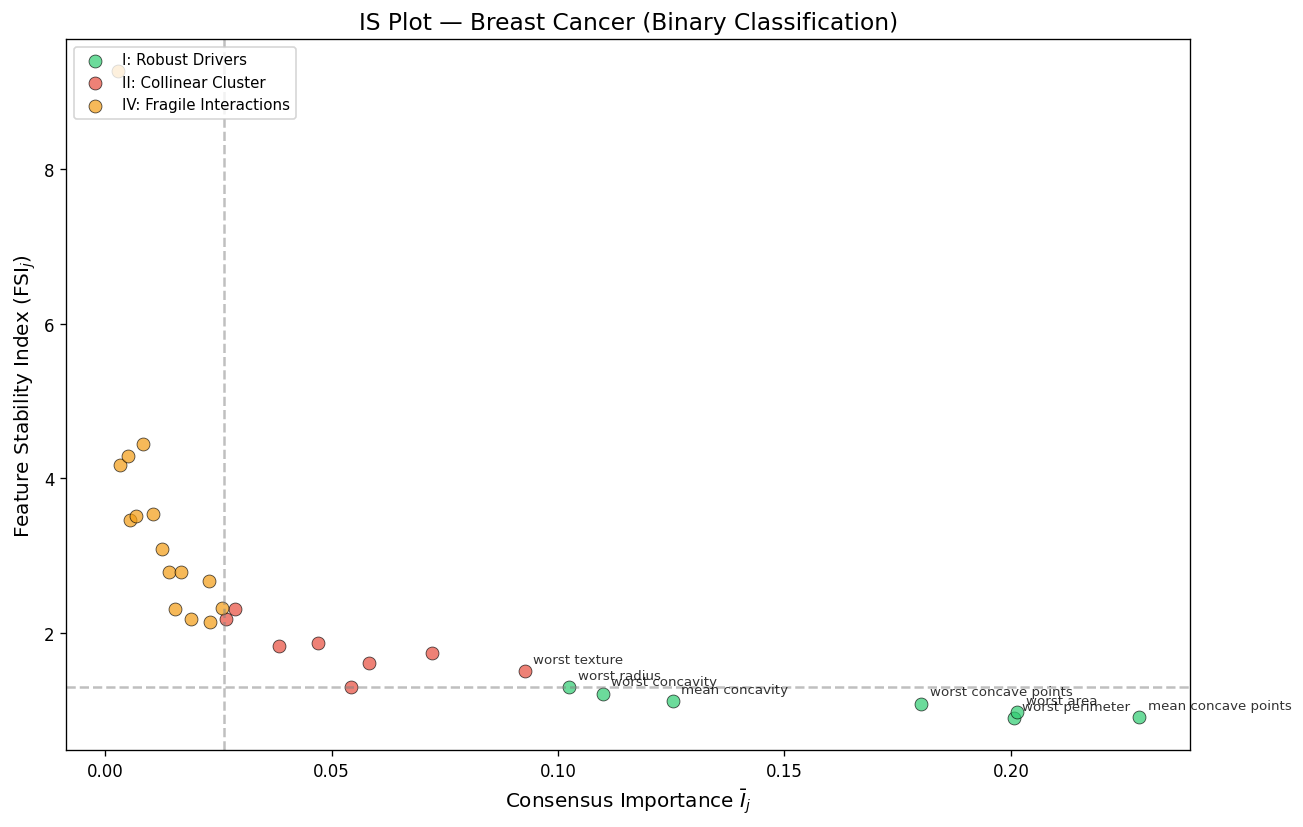

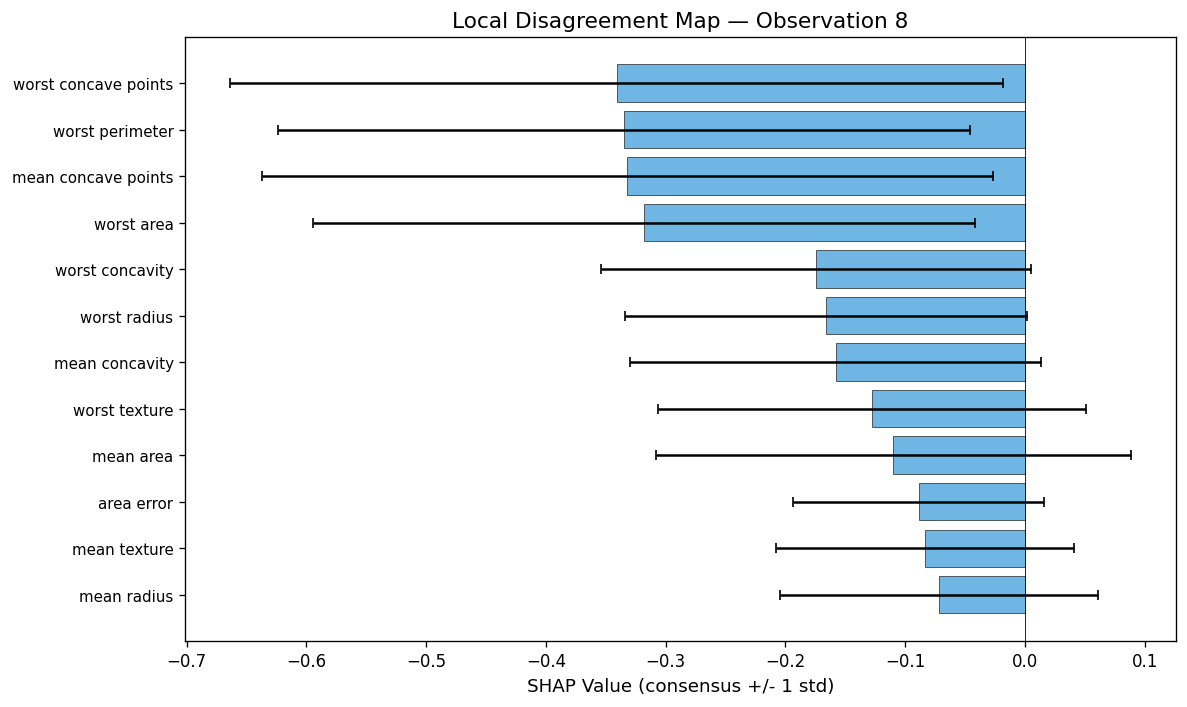

In [35]:
# IS plots and disagreement maps from the script
show_figure('is_plot_california.png')
show_figure('is_plot_breast_cancer.png')
show_figure('disagreement_breast_cancer.png')

---
## 5. Epsilon Sensitivity

In [36]:
eps = load('epsilon_sensitivity')
if eps:
    rows = []
    for e, m in sorted(eps.items(), key=lambda x: float(x[0])):
        rows.append({
            'Epsilon': float(e),
            'Stability': m['stability'],
            'Accuracy': float(np.mean(m['acc_runs'])),
            'Models Passing': f"{np.mean(m['n_passing']):.0f} ± {np.std(m['n_passing']):.0f}",
            'K_eff': f"{np.mean(m['k_eff']):.0f} ± {np.std(m['k_eff']):.0f}",
        })
    display(pd.DataFrame(rows).set_index('Epsilon'))

    # Quick plot
    eps_vals = sorted(float(e) for e in eps.keys())
    def _eps_key(eps_dict, val):
        for k in [str(val), f"{val:.2f}", f"{val}"]:
            if k in eps_dict:
                return k
        return str(val)
    stabs = [eps[_eps_key(eps, e)]['stability'] for e in eps_vals]
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(eps_vals, stabs, 'o-', color='#2ecc71', linewidth=2, markersize=8)
    ax.set_xlabel('Epsilon (ε)')
    ax.set_ylabel('Stability')
    ax.set_title('Stability vs Performance Filter Threshold')
    plt.tight_layout()
    plt.show()

⚠ ../results/tables/epsilon_sensitivity.json not found — run the corresponding experiment first.


---
## 6. Ablation Studies

In [37]:
abl = load('ablation')
if abl:
    for rho_key in sorted(abl.keys(), key=float):
        print(f'\n=== ρ = {rho_key} ===')
        for param, values in abl[rho_key].items():
            rows = []
            for val, m in sorted(values.items(), key=lambda x: float(x[0])):
                rows.append({
                    param: float(val),
                    'Stability': m['stability'],
                    'Accuracy': m['accuracy_mean'],
                })
            display(pd.DataFrame(rows).set_index(param).round(4))

⚠ ../results/tables/ablation.json not found — run the corresponding experiment first.


In [38]:
# Ablation line plots (one subplot per parameter, lines per rho)
if abl:
    params = list(next(iter(abl.values())).keys())
    rho_keys = sorted(abl.keys(), key=float)
    rho_colors = {r: c for r, c in zip(rho_keys, ['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])}

    fig, axes = plt.subplots(1, len(params), figsize=(5 * len(params), 4), sharey=True)
    if len(params) == 1:
        axes = [axes]

    for ax, param in zip(axes, params):
        for rho_key in rho_keys:
            vals_dict = abl[rho_key][param]
            xs = sorted(float(v) for v in vals_dict.keys())
            ys = [vals_dict[str(x) if str(x) in vals_dict else str(int(x))]['stability'] for x in xs]
            ax.plot(xs, ys, 'o-', label=f'ρ={rho_key}', color=rho_colors[rho_key], linewidth=2)
        ax.set_xlabel(param)
        ax.set_title(f'Stability vs {param}')
        ax.legend(fontsize=9)

    axes[0].set_ylabel('Stability')
    fig.suptitle('Ablation Studies', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

---
## 6.5 Variance Decomposition

> **Caveat:** `1 − stability` is a proxy for instability, not a proper variance.
> Pairwise Spearman ρ does not yield an exact additive decomposition;
> the ratios below are indicative, not exact.


In [39]:
vd = load('variance_decomposition')
if vd:
    rows = []
    for cond, methods in vd.items():
        for method, metrics in methods.items():
            rows.append({
                'Condition': cond,
                'Method': method,
                'Stability': metrics['stability'],
            })
    display(pd.DataFrame(rows).pivot_table(index='Method', columns='Condition', values='Stability').round(4))


⚠ ../results/tables/variance_decomposition.json not found — run the corresponding experiment first.


### Crossed ANOVA (Exact Decomposition)

Exact two-way ANOVA on a 7×7 crossed design — replaces the `1 − stability` proxy above.

In [40]:
vdc = load('variance_decomposition_crossed')
if vdc:
    rows = []
    for method, metrics in vdc.items():
        rows.append({
            'Method': method,
            'Data Var %': f"{metrics['data_var_frac']*100:.1f}%",
            'Model Var %': f"{metrics['model_var_frac']*100:.1f}%",
            'Residual %': f"{metrics['residual_var_frac']*100:.1f}%",
        })
    display(pd.DataFrame(rows).set_index('Method'))
else:
    print('variance_decomposition_crossed results not found — run the experiment first.')

⚠ ../results/tables/variance_decomposition_crossed.json not found — run the corresponding experiment first.
variance_decomposition_crossed results not found — run the experiment first.


---
## 6.6 First-Mover Bias Isolation

> Shows how importance concentration within a correlated group grows with
> tree count for a single sequential model, while independent ensembles
> remain equitable.

In [41]:
fmb = load('first_mover_bias')
if fmb:
    rows = []
    for n_est, m in sorted(fmb.items(), key=lambda x: int(x[0])):
        rows.append({
            'n_estimators': int(n_est),
            'Single Model Conc.': m['single_concentration'],
            'Independent Ens. Conc.': m['independent_concentration'],
            'Ratio': m['single_concentration'] / (m['independent_concentration'] + 1e-10),
        })
    display(pd.DataFrame(rows).set_index('n_estimators').round(4))

    # Line plot
    xs = [int(k) for k in sorted(fmb.keys(), key=int)]
    sc = [fmb[str(n)]['single_concentration'] for n in xs]
    dc = [fmb[str(n)]['independent_concentration'] for n in xs]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(xs, sc, 's-', color='#e74c3c', label='Single Sequential Model', linewidth=2, markersize=7)
    ax.plot(xs, dc, 'o-', color='#2ecc71', label='Independent Ensemble', linewidth=2, markersize=7)
    ax.axhline(y=0.2, color='black', linestyle='--', alpha=0.5, label='Perfect equity (1/5)')
    ax.set_xlabel('Number of Trees')
    ax.set_ylabel('Concentration (max/sum)')
    ax.set_title('First-Mover Bias Isolation')
    ax.set_xscale('log')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

show_figure('first_mover_bias_isolation.png')

⚠ ../results/tables/first_mover_bias.json not found — run the corresponding experiment first.
⚠ ../results/figures/first_mover_bias_isolation.png not found.


---
## 6.5 First-Mover Concentration Visualization
Per-feature importance concentration under single vs independent models.

,Concentration
Method,
Single Best,0.2116
Large Single Model,0.2126
DASH (MaxMin),0.2094


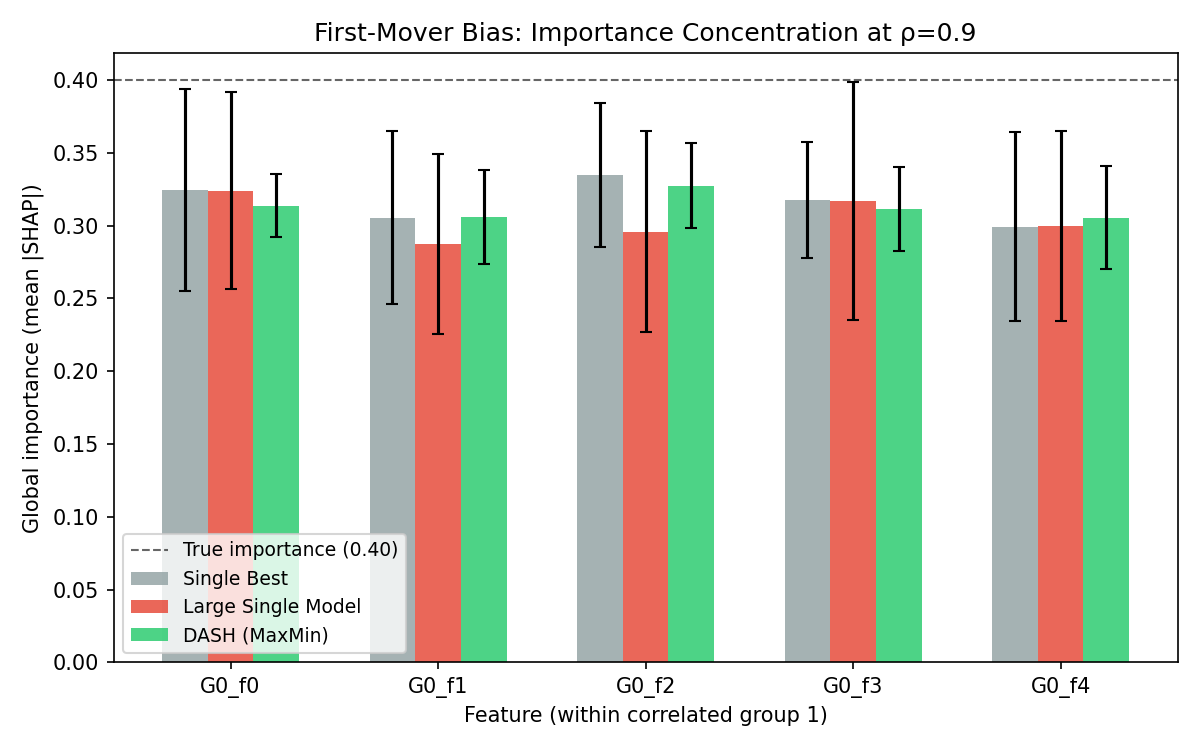

In [42]:
fmv = load('first_mover_visualization')
if fmv:
    rows = []
    for method, mdata in fmv.items():
        rows.append({'Method': method, 'Concentration': mdata['concentration']})
    display(pd.DataFrame(rows).set_index('Method').round(4))
show_figure('first_mover_concentration.png')
if not fmv:
    print('first_mover_visualization JSON not found — showing figure only if available.')


---
## 6.6 Success Criteria
Pre-specified pass/fail validation against the linear sweep results.

In [43]:
# Success criteria are evaluated inline by the runner.
# The experiment just re-runs linear_sweep and checks criteria.
# Display the sweep results at rho=0.9 as a quick summary:
if sweep and '0.9' in sweep:
    rho09 = sweep['0.9']
    dash_stab = rho09.get('DASH (MaxMin)', {}).get('stability', float('nan'))
    sb_stab = rho09.get('Single Best', {}).get('stability', float('nan'))
    print('Success Criteria Quick Check (ρ=0.9):')
    print(f'  DASH stability:        {dash_stab:.4f} (target: > SB)')
    print(f'  Single Best stability:  {sb_stab:.4f}')
    print(f'  DASH > SB:             {"PASS" if dash_stab > sb_stab else "FAIL"}')
else:
    print('Sweep results not available — run linear_sweep first.')


Success Criteria Quick Check (ρ=0.9):
  DASH stability:        0.9763 (target: > SB)
  Single Best stability:  0.9576
  DASH > SB:             PASS


---
## 6.7 Background Size Sensitivity
SHAP background sample count B ∈ {50, 100, 200, 500} at ρ=0.9.

In [44]:
bg = load('background_sensitivity')
if bg:
    print('Background Size Sensitivity at ρ=0.9:')
    print(f'{"B":>6} {"Stability":>10} {"±SE":>8} {"Accuracy":>10} {"Equity(CV)↓":>12}')
    print('=' * 55)
    for B in ['50', '100', '200', '500']:
        if B not in bg:
            continue
        d = bg[B]
        print(f'{B:>6} {d["stability"]:10.4f} {d["stability_se"]:8.4f} '
              f'{d["accuracy_mean"]:10.4f} {d["equity_mean"]:12.4f}')
else:
    print('background_sensitivity results not found — run the experiment first.')


⚠ ../results/tables/background_sensitivity.json not found — run the corresponding experiment first.
background_sensitivity results not found — run the experiment first.


---
## 6.8 Asymmetric Causal DGP (Appendix D)

Tests whether DASH over-equalizes when f0 is causal and f1 is a passive correlate.
Sweeps ρ ∈ {0.5, 0.7, 0.9, 0.95}.

In [45]:
asym = load('asymmetric_dgp')
if asym:
    rows = []
    for rho, methods in sorted(asym.items(), key=lambda x: float(x[0])):
        for method, m in methods.items():
            if not isinstance(m, dict):
                continue
            rows.append({
                'rho': float(rho),
                'Method': method,
                'Stability': round(m.get('stability', float('nan')), 4),
                'Bias f0': round(m.get('bias_f0', float('nan')), 4),
                'Passive leak f1': round(m.get('passive_leak_f1', float('nan')), 4),
            })
    df_asym = pd.DataFrame(rows)
    print('Asymmetric Causal DGP — Stability by Method and Correlation')
    display(df_asym.pivot_table(index='Method', columns='rho', values='Stability').round(4))
    print('\nAttribution Bias at ρ=0.9 (f0 target: ~0.0 bias; f1 target: ~0.0 leak):')
    df_09 = df_asym[df_asym['rho'] == 0.9][['Method', 'Bias f0', 'Passive leak f1']].set_index('Method')
    display(df_09)
else:
    print('asymmetric_dgp results not found — run the experiment first.')

⚠ ../results/tables/asymmetric_dgp.json not found — run the corresponding experiment first.
asymmetric_dgp results not found — run the experiment first.


---
## 6.8 Asymmetric Causal DGP
Tests whether DASH over-equalizes when f0 is causal and f1 is a passive correlate (Appendix D, Table 7).


In [46]:
asym = load('asymmetric_dgp')
if asym:
    rows = []
    for rho_key in sorted(asym.keys(), key=float):
        for method, mdata in asym[rho_key].items():
            rows.append({
                'rho': float(rho_key),
                'Method': method,
                'Stability': mdata.get('stability'),
                'Bias(f0)': mdata.get('bias_f0'),
                'Passive Leak(f1)': mdata.get('passive_leak_f1'),
            })
    display(pd.DataFrame(rows).pivot_table(
        index='Method', columns='rho',
        values=['Stability', 'Bias(f0)', 'Passive Leak(f1)'],
    ).round(4))
else:
    print('asymmetric_dgp results not found — run the experiment first.')


⚠ ../results/tables/asymmetric_dgp.json not found — run the corresponding experiment first.
asymmetric_dgp results not found — run the experiment first.


---
## 6.9 Crossed Variance Decomposition (ANOVA)
Exact two-way ANOVA: data-sampling vs model-selection variance (7x7 crossed design).


In [47]:
vdc = load('variance_decomposition_crossed')
if vdc:
    rows = []
    for method, mdata in vdc.items():
        rows.append({
            'Method': method,
            'Data Var %': f"{mdata['data_var_frac']:.1%}",
            'Model Var %': f"{mdata['model_var_frac']:.1%}",
            'Residual Var %': f"{mdata['residual_var_frac']:.1%}",
        })
    display(pd.DataFrame(rows).set_index('Method'))
else:
    print('variance_decomposition_crossed results not found — run the experiment first.')


⚠ ../results/tables/variance_decomposition_crossed.json not found — run the corresponding experiment first.
variance_decomposition_crossed results not found — run the experiment first.


---
## 7. Cross-Experiment Summary

Quick comparison of DASH (MaxMin) stability across all experiments.

In [48]:
summary_rows = []

# Synthetic sweep at rho=0.9
if sweep and '0.9' in sweep and 'DASH (MaxMin)' in sweep['0.9']:
    m = sweep['0.9']['DASH (MaxMin)']
    summary_rows.append({
        'Experiment': 'Linear (ρ=0.9)',
        'Stability': m['stability'],
        'DGP Agreement': m.get('accuracy_mean'),
    })

if nl and '0.9' in nl and 'DASH (MaxMin)' in nl['0.9']:
    m = nl['0.9']['DASH (MaxMin)']
    summary_rows.append({
        'Experiment': 'Nonlinear (ρ=0.9)',
        'Stability': m['stability'],
    })

for name, json_name in [('California', 'california_housing'),
                         ('Breast Cancer', 'breast_cancer'),
                         ('Superconductor', 'superconductor')]:
    data = load(json_name)
    if data and 'DASH (MaxMin)' in data:
        summary_rows.append({
            'Experiment': name,
            'Stability': data['DASH (MaxMin)']['stability'],
        })

if summary_rows:
    display(pd.DataFrame(summary_rows).set_index('Experiment').round(4))
else:
    print('No results available yet.')

⚠ ../results/tables/california_housing.json not found — run the corresponding experiment first.
⚠ ../results/tables/breast_cancer.json not found — run the corresponding experiment first.
⚠ ../results/tables/superconductor.json not found — run the corresponding experiment first.


,Stability,DGP Agreement
Experiment,,
Linear (ρ=0.9),0.9763,0.9878
